# Target Distribution

y_HY3 shape: (909, 1)
y_HY4_3 shape: (909, 1)


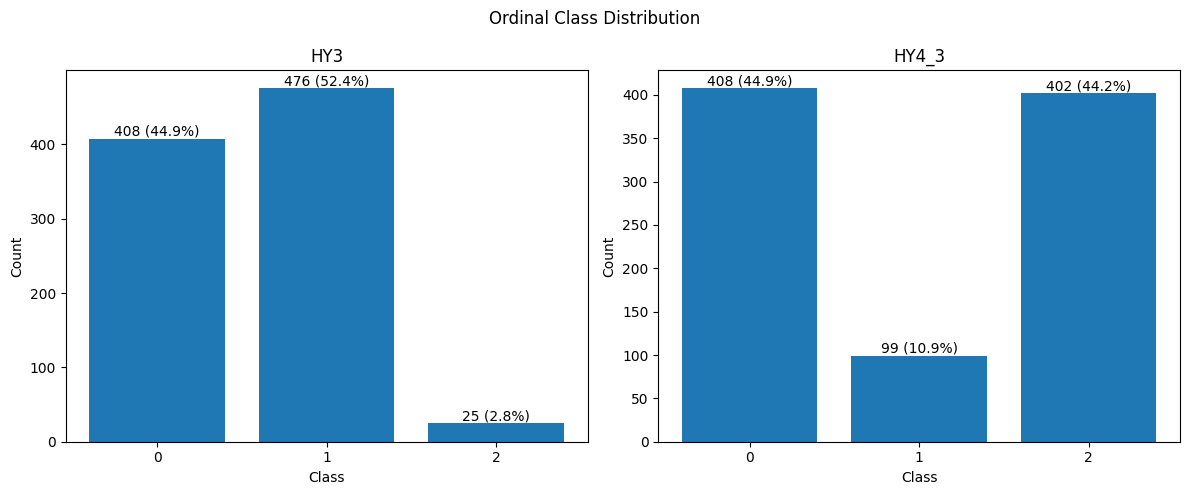

In [1]:
import pandas as pd
import json
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parents[3]

import matplotlib.pyplot as plt


y_HY3 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3.csv", index_col=0)
y_HY43 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY43.csv", index_col=0)
print("y_HY3 shape:", y_HY3.shape)
print("y_HY4_3 shape:", y_HY43.shape)


datasets = {
    "HY3": y_HY3,
    'HY4_3': y_HY43,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    
    counts = df.iloc[:,0].value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    
    bars = ax.bar(counts.index.astype(str), counts.values)
    
    # añadir texto con conteo y porcentaje
    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(i, count, f"{count} ({pct:.1f}%)", 
                ha='center', va='bottom')
    
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.suptitle("Ordinal Class Distribution")
plt.tight_layout()
plt.show()

# Files

In [2]:
import os
import re

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/Domain_data.json", "r") as archivo:
    full_domain = json.load(archivo)

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/UPDRS_Domain_data.json", "r") as archivo:
    updrs_domain = json.load(archivo)

X_multiples= { 'X_STATS':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_STATS.csv', 
                    'X_V06_STATS': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_V06+STATS.csv',
                      'X_V06_DELTA': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_V06+Deltas.csv'}

y_multiples = { 'HY3': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3.csv',
                'HY43': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY43.csv',
                }



output_path= project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/Multiclass/"

dominios_full = {
    'X_STATS': { 
        'motor': full_domain['SC_data'] + full_domain['M_data_STATS'],
        'non_motor': full_domain['NM_data_STATS']
    },

    'X_V06_STATS': {
        'motor': full_domain['SC_data'] +full_domain['M_data_V06'] + full_domain['M_data_STATS'],
        'non_motor': full_domain['SC_data'] + full_domain['NM_data_V06'] + full_domain['NM_data_STATS']
    },

    'X_V06_DELTA': {
        'motor': full_domain['SC_data'] + full_domain['M_data_V06'] + full_domain['M_data_DELTA'],
        'non_motor': full_domain['NM_data_V06'] + full_domain['NM_data_DELTA']
    }
}

dominios_updrs = {
    'X_STATS': {

        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_STATS'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_STATS'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_STATS']
    },

    'X_V06_STATS': {
        
        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_V06'] + updrs_domain['UPDRS_MOTOR_STATS'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_V06'] + updrs_domain['UPDRS_IMPACTO_MOTOR_STATS'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_V06'] + updrs_domain['UPDRS_NO_MOTOR_STATS']
    },

    'X_V06_DELTA': {
        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_V06'] + updrs_domain['UPDRS_MOTOR_delta'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_V06'] + updrs_domain['UPDRS_IMPACTO_MOTOR_delta'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_V06'] + updrs_domain['UPDRS_NO_MOTOR_delta']
    }
}

cols_updrs_full={}
for val in dominios_updrs:
    cols_updrs_val=[]
    for val_sub in dominios_updrs[val]:
        print(f"Evaluating domain: {val} - {val_sub}")
        cols_updrs_val+=dominios_updrs[val][val_sub]
    cols_updrs_full[val]=cols_updrs_val

cols_updrs_full['X_V06_STATS']=list(set(cols_updrs_full['X_V06_STATS']))
cols_updrs_full['X_STATS']=list(set(cols_updrs_full['X_STATS']))
cols_updrs_full['X_V06_DELTA']=list(set(cols_updrs_full['X_V06_DELTA']))


Evaluating domain: X_STATS - examen_motor
Evaluating domain: X_STATS - impacto_motor
Evaluating domain: X_STATS - non_motor
Evaluating domain: X_V06_STATS - examen_motor
Evaluating domain: X_V06_STATS - impacto_motor
Evaluating domain: X_V06_STATS - non_motor
Evaluating domain: X_V06_DELTA - examen_motor
Evaluating domain: X_V06_DELTA - impacto_motor
Evaluating domain: X_V06_DELTA - non_motor


# Performance Function Binary 

In [3]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
)


def _compute_metrics_binary(
    y_true,
    y_pred,
    y_proba=None,
    positive_label=1,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = np.asarray(y_pred, dtype=int).ravel()

    # =========================
    # GLOBAL METRICS
    # =========================
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)

    # =========================
    # COST MATRIX
    # =========================
    # Formato:
    # cost_matrix[true_class, predicted_class]
    #
    # Por defecto:
    #   TN = 0
    #   FP = 1
    #   FN = 5
    #   TP = 0
    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_cost_mean"] = sample_costs.mean()
    metrics["misclassification_cost_total"] = sample_costs.sum()
    metrics["misclassification_score"] = -sample_costs.mean()

    for cls in [0, 1]:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = np.nan

    # =========================
    # AUC
    # =========================
    if y_proba is not None:
        try:
            y_proba = np.asarray(y_proba)

            if y_proba.ndim == 1:
                pos_scores = y_proba
            elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                pos_scores = y_proba[:, 1]
            else:
                pos_scores = None

            metrics["auc"] = roc_auc_score(y_true, pos_scores) if pos_scores is not None else np.nan
        except Exception:
            metrics["auc"] = np.nan
    else:
        metrics["auc"] = np.nan

    # =========================
    # PER-CLASS METRICS
    # =========================
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    for i, cls in enumerate([0, 1]):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    # =========================
    # CONFUSION-MATRIX METRICS
    # =========================
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["npv"] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    metrics["fpr"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics["fnr"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


def _build_row_binary(results, model_name):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "target_type": "binary",
        "classes": [0, 1],
        "n_classes": 2,
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        train_vals = [r["train"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

        row[f"{metric}_train_mean"] = np.mean(train_vals)
        row[f"{metric}_train_std"] = np.std(train_vals, ddof=1)

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    return row


def evaluate_model_10x10_metrics_binary(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    positive_label=1,
    cost_matrix=None,
):
    # =========================
    # CONVERT TO NUMPY
    # =========================
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    unique_classes = np.unique(y_arr)
    if len(unique_classes) != 2:
        raise ValueError(
            f"El target y debe ser binario. Clases encontradas: {unique_classes}"
        )

    # Opcional: normalizar etiquetas a {0, 1}
    # Si ya vienen como 0 y 1, no cambia nada.
    if not np.array_equal(np.sort(unique_classes), np.array([0, 1])):
        mapping = {unique_classes[0]: 0, unique_classes[1]: 1}
        y_arr = np.vectorize(mapping.get)(y_arr)
        positive_label = 1

    all_rows = []

    # =========================
    # LOOP MODELS
    # =========================
    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        # =========================
        # OUTER LOOP
        # =========================
        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_scores = []

            # =========================
            # INNER LOOP
            # =========================
            for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                est = clone(model)
                est.fit(X_train_inner, y_train_inner)

                y_pred_val = est.predict(X_val_inner)

                y_proba_val = (
                    est.predict_proba(X_val_inner)
                    if hasattr(est, "predict_proba")
                    else None
                )

                inner_scores.append(
                    _compute_metrics_binary(
                        y_true=y_val_inner,
                        y_pred=y_pred_val,
                        y_proba=y_proba_val,
                        positive_label=positive_label,
                        cost_matrix=cost_matrix
                    )
                )

            cv_mean_scores = _mean_metrics(inner_scores)

            # =========================
            # FINAL MODEL (OUTER TRAIN + OUTER TEST)
            # =========================
            final_model = clone(model)
            final_model.fit(X_train_outer, y_train_outer)

            # TRAIN METRICS
            y_pred_train = final_model.predict(X_train_outer)

            y_proba_train = (
                final_model.predict_proba(X_train_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            train_scores = _compute_metrics_binary(
                y_true=y_train_outer,
                y_pred=y_pred_train,
                y_proba=y_proba_train,
                positive_label=positive_label,
                cost_matrix=cost_matrix
            )

            # TEST METRICS
            y_pred_test = final_model.predict(X_test_outer)

            y_proba_test = (
                final_model.predict_proba(X_test_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            test_scores = _compute_metrics_binary(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test,
                positive_label=positive_label,
                cost_matrix=cost_matrix
            )

            results.append({
                "cv": cv_mean_scores,
                "train": train_scores,
                "test": test_scores
            })

        # =========================
        # SAVE RESULT ROW
        # =========================
        all_rows.append(
            _build_row_binary(
                results=results,
                model_name=model_name,
            )
        )

    return pd.DataFrame(all_rows)

# Models Baseline

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


classification_models_WB = {

    "decision_tree": DecisionTreeClassifier(
        random_state=42,
        class_weight = 'balanced'
    ),

    "random_forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ),

    "extra_trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ),

    "xgboost": XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
       
    ),

    "adaboost": AdaBoostClassifier(
        algorithm="SAMME", 
        random_state=42
    ),

    "svm": SVC(
        kernel="rbf",
        probability=True,  
        random_state=42,
        class_weight = 'balanced'
    ),

    "logistic_regression": LogisticRegression(
        random_state=42,
        n_jobs=-1,
        max_iter=10000,
        class_weight = 'balanced'
    ),

    "knn": KNeighborsClassifier(
        n_jobs=-1
    ),

    "gaussian_nb": GaussianNB()
}

classification_models_WB = {
    name: Pipeline([
        ("model", model)])
    for name, model in classification_models_WB.items()
}

# PairWise + Binnings Analysis 

In [52]:
# UPDERS DOMAINS
list_results = []
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)[cols_updrs_full[val]]
    print(f"    Shape in X: {X.shape}")
    for target in ["HY3", "HY43"]:
        print(f"    Evaluating target: {target}")
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)
        for pair in ['0 vs 1','0 vs 2', '1 vs 2', '0 vs 1-2', '1 vs 0-2', '2 vs 0-1']: 
            print(f"        Evaluating pair: {pair}")
            y_binary = y.copy()
            if pair == '0 vs 1':
                mask = (y_binary.iloc[:, 0] == 0) | (y_binary.iloc[:, 0] == 1)
                y_binary = y_binary[mask]
                y_binary.iloc[:, 0] = y_binary.iloc[:, 0].replace({0: 0, 1: 1})
                X_binary = X.loc[y_binary.index]
            elif pair == '0 vs 2':
                mask = (y_binary.iloc[:, 0] == 0) | (y_binary.iloc[:, 0] == 2)
                y_binary = y_binary[mask]
                y_binary.iloc[:, 0] = y_binary.iloc[:, 0].replace({0: 0, 2: 1})
                X_binary = X.loc[y_binary.index]
            elif pair == '1 vs 2':
                mask = (y_binary.iloc[:, 0] == 1) | (y_binary.iloc[:, 0] == 2)
                y_binary = y_binary[mask]
                y_binary.iloc[:, 0] = y_binary.iloc[:, 0].replace({1: 0, 2: 1})
                X_binary = X.loc[y_binary.index]
            elif pair == '0 vs 1-2':
                y_binary.iloc[:, 0] = y_binary.iloc[:, 0].replace({0: 0, 1: 1, 2: 1})
                X_binary = X.loc[y_binary.index]
            elif pair == '0-1 vs 2':
                y_binary.iloc[:, 0] = y_binary.iloc[:, 0].replace({0: 0, 1: 0, 2: 1})
                X_binary = X.loc[y_binary.index]
            elif pair == '1 vs 0-2':
                y_binary.iloc[:, 0] = y_binary.iloc[:, 0].replace({1: 0, 0: 1, 2: 1})
                X_binary = X.loc[y_binary.index]
            elif pair == '2 vs 0-1':
                y_binary.iloc[:, 0] = y_binary.iloc[:, 0].replace({2: 0, 0: 1, 1: 1})
                X_binary = X.loc[y_binary.index]

            print(f"            Shape in X_binary: {X_binary.shape}")
            print(f"            Shape in y_binary: {y_binary.shape}")
   
            df=evaluate_model_10x10_metrics_binary(model_dict=classification_models_WB, 
                                                    X=X_binary, 
                                                    y=y_binary)
           
            df['X_transfromation'] = 'None_sacler'
            df['Pair'] = pair
            df['Target'] = target
            df['X_Processing'] = val
            list_results.append(df)

final_df = pd.concat(list_results, ignore_index=True)
final_df.to_csv(output_path / "MULTICLASS_BOTTLE_NECK_PAIRWISE_RESULTS.csv", index=False)
final_df

Evaluating domain: X_STATS
    Shape in X: (909, 301)
    Evaluating target: HY3
        Evaluating pair: 0 vs 1
            Shape in X_binary: (884, 301)
            Shape in y_binary: (884, 1)
Evaluating model: decision_tree
Evaluating model: random_forest
Evaluating model: extra_trees
Evaluating model: xgboost


KeyboardInterrupt: 

In [ ]:
bottel_neck_results = pd.read_csv(output_path / "MULTICLASS_BOTTLE_NECK_PAIRWISE_RESULTS.csv")
bottel_neck_results_hy3 = bottel_neck_results[bottel_neck_results['Target'] == 'HY3']
bottel_neck_results_hy43 = bottel_neck_results[bottel_neck_results['Target'] == 'HY43']

In [ ]:
bottel_neck_results_hy3 

,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_test_mean,accuracy_test_std,f1_cv_mean,f1_cv_std,...,fpr_test_mean,fpr_test_std,fnr_cv_mean,fnr_cv_std,fnr_test_mean,fnr_test_std,X_transfromation,Pair,Target,X_Processing
0,decision_tree,binary,"[0, 1]",2,0.870215,0.011278,0.874436,1.626178e-02,0.879787,0.010979,...,0.115447,0.023873,0.116000,0.017442,0.134266,0.023029,None_sacler,0 vs 1,HY3,X_STATS
1,random_forest,binary,"[0, 1]",2,0.926344,0.006481,0.921805,8.825472e-03,0.929905,0.006425,...,0.043902,0.015895,0.089900,0.011040,0.107692,0.018116,None_sacler,0 vs 1,HY3,X_STATS
2,extra_trees,binary,"[0, 1]",2,0.922473,0.007000,0.920301,1.186181e-02,0.926749,0.006784,...,0.048780,0.021680,0.086800,0.010465,0.106294,0.018590,None_sacler,0 vs 1,HY3,X_STATS
3,xgboost,binary,"[0, 1]",2,0.918172,0.006593,0.915789,1.080895e-02,0.922522,0.006582,...,0.061789,0.027424,0.093000,0.011879,0.103497,0.015035,None_sacler,0 vs 1,HY3,X_STATS
4,adaboost,binary,"[0, 1]",2,0.914247,0.008361,0.911654,1.256262e-02,0.919005,0.008104,...,0.078862,0.027915,0.094700,0.012841,0.096503,0.022065,None_sacler,0 vs 1,HY3,X_STATS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,adaboost,binary,"[0, 1]",2,0.974084,0.004124,0.968864,4.649434e-03,0.986784,0.002107,...,0.812500,0.121478,0.006344,0.002631,0.007547,0.005031,None_sacler,2 vs 0-1,HY3,X_V06_DELTA
266,svm,binary,"[0, 1]",2,0.920262,0.013874,0.916484,1.580713e-02,0.957449,0.007671,...,0.350000,0.141912,0.074355,0.013332,0.075472,0.018054,None_sacler,2 vs 0-1,HY3,X_V06_DELTA
267,logistic_regression,binary,"[0, 1]",2,0.968953,0.003934,0.967766,7.077595e-03,0.984056,0.002032,...,0.625000,0.176777,0.015484,0.003102,0.014340,0.010342,None_sacler,2 vs 0-1,HY3,X_V06_DELTA
268,knn,binary,"[0, 1]",2,0.973874,0.000166,0.970696,1.170278e-16,0.986764,0.000083,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,None_sacler,2 vs 0-1,HY3,X_V06_DELTA


In [ ]:
bottel_neck_results_hy43

,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_test_mean,accuracy_test_std,f1_cv_mean,f1_cv_std,...,fpr_test_mean,fpr_test_std,fnr_cv_mean,fnr_cv_std,fnr_test_mean,fnr_test_std,X_transfromation,Pair,Target,X_Processing
54,decision_tree,binary,"[0, 1]",2,0.838972,0.010556,0.853595,0.028771,0.584739,0.032542,...,0.078049,0.029238,0.417619,0.040596,0.426667,0.062460,None_sacler,0 vs 1,HY43,X_STATS
55,random_forest,binary,"[0, 1]",2,0.922150,0.007490,0.909150,0.014270,0.755562,0.029505,...,0.013008,0.013924,0.371905,0.038650,0.410000,0.087560,None_sacler,0 vs 1,HY43,X_STATS
56,extra_trees,binary,"[0, 1]",2,0.923364,0.009093,0.911765,0.010334,0.761316,0.033657,...,0.011382,0.010975,0.362857,0.042104,0.403333,0.074453,None_sacler,0 vs 1,HY43,X_STATS
57,xgboost,binary,"[0, 1]",2,0.911682,0.009785,0.909804,0.015650,0.746095,0.028573,...,0.031707,0.018559,0.331905,0.029953,0.330000,0.059732,None_sacler,0 vs 1,HY43,X_STATS
58,adaboost,binary,"[0, 1]",2,0.909439,0.009875,0.898693,0.014203,0.738429,0.032255,...,0.034959,0.013304,0.339524,0.038165,0.373333,0.078253,None_sacler,0 vs 1,HY43,X_STATS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,adaboost,binary,"[0, 1]",2,0.858586,0.011784,0.854945,0.025740,0.872384,0.011039,...,0.145455,0.036380,0.135794,0.014954,0.144737,0.035225,None_sacler,2 vs 0-1,HY43,X_V06_DELTA
320,svm,binary,"[0, 1]",2,0.855497,0.017296,0.854579,0.021777,0.876564,0.015031,...,0.199174,0.033161,0.084019,0.018792,0.102632,0.026352,None_sacler,2 vs 0-1,HY43,X_V06_DELTA
321,logistic_regression,binary,"[0, 1]",2,0.842827,0.017507,0.837729,0.020939,0.860315,0.015705,...,0.181818,0.043383,0.135234,0.017512,0.146711,0.035231,None_sacler,2 vs 0-1,HY43,X_V06_DELTA
322,knn,binary,"[0, 1]",2,0.655236,0.010656,0.650549,0.011084,0.763791,0.005899,...,0.780165,0.024701,0.005701,0.002870,0.006579,0.006935,None_sacler,2 vs 0-1,HY43,X_V06_DELTA


# LDA vs Bottle Neck

## Performance Function

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


# =========================================================
# METRICS
# =========================================================
def _compute_metrics_binary(
    y_true,
    y_pred,
    y_proba=None,
    positive_label=1,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = np.asarray(y_pred, dtype=int).ravel()

    # =========================
    # GLOBAL METRICS
    # =========================
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)

    # =========================
    # COST MATRIX
    # =========================
    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_cost_mean"] = sample_costs.mean()
    metrics["misclassification_cost_total"] = sample_costs.sum()
    metrics["misclassification_score"] = -sample_costs.mean()

    for cls in [0, 1]:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = np.nan

    # =========================
    # AUC
    # =========================
    if y_proba is not None:
        try:
            y_proba = np.asarray(y_proba)

            if y_proba.ndim == 1:
                pos_scores = y_proba
            elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                pos_scores = y_proba[:, 1]
            else:
                pos_scores = None

            metrics["auc"] = roc_auc_score(y_true, pos_scores) if pos_scores is not None else np.nan
        except Exception:
            metrics["auc"] = np.nan
    else:
        metrics["auc"] = np.nan

    # =========================
    # PER-CLASS METRICS
    # =========================
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    for i, cls in enumerate([0, 1]):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    # =========================
    # CONFUSION MATRIX METRICS
    # =========================
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["npv"] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    metrics["fpr"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics["fnr"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


# =========================================================
# TASK DEFINITIONS
# =========================================================
def _get_task_definitions():
    return [
        {
            "task_name": "0_vs_1",
            "task_type": "pairwise_binary_lda",
            "classes_used": [0, 1],
            "positive_label_original": 1,
        },
        {
            "task_name": "0_vs_2",
            "task_type": "pairwise_binary_lda",
            "classes_used": [0, 2],
            "positive_label_original": 2,
        },
        {
            "task_name": "1_vs_2",
            "task_type": "pairwise_binary_lda",
            "classes_used": [1, 2],
            "positive_label_original": 2,
        },
        {
            "task_name": "0_vs_1_2",
            "task_type": "grouped_multiclass_lda",
            "classes_used": [0, 1, 2],
            "positive_group": [1, 2],
            "negative_group": [0],
            "positive_label_original": [1, 2],
        },
        {
            "task_name": "0_1_vs_2",
            "task_type": "grouped_multiclass_lda",
            "classes_used": [0, 1, 2],
            "positive_group": [1,0],
            "negative_group": [2],
            "positive_label_original": [1,0],
        },
        {
            "task_name": "1_vs_0_2",
            "task_type": "grouped_multiclass_lda",
            "classes_used": [0, 1, 2],
            "positive_group": [1],
            "negative_group": [0, 2],
            "positive_label_original": [1],
        },
        {
            "task_name": "2_vs_0_1",
            "task_type": "grouped_multiclass_lda",
            "classes_used": [0, 1, 2],
            "positive_group": [2],
            "negative_group": [0, 1],
            "positive_label_original": [2],
        },
    ]


# =========================================================
# TARGET / DATA HELPERS
# =========================================================
def _prepare_pairwise_dataset(X, y, cls_a, cls_b):
    mask = np.isin(y, [cls_a, cls_b])

    X_sub = X[mask]
    y_sub = y[mask]

    mapping = {cls_a: 0, cls_b: 1}
    y_bin = np.vectorize(mapping.get)(y_sub).astype(int)

    return X_sub, y_bin


def _recode_grouped_target(y, positive_group):
    y = np.asarray(y).ravel()
    return np.isin(y, positive_group).astype(int)


def _safe_fit_lda(X_train, y_train, n_components):
    y_train = np.asarray(y_train).ravel()
    n_classes = len(np.unique(y_train))
    n_features = X_train.shape[1]

    max_components = min(n_classes - 1, n_features)

    if max_components < 1:
        raise ValueError(
            f"No se puede ajustar LDA: n_classes={n_classes}, n_features={n_features}"
        )

    lda = LinearDiscriminantAnalysis(
        n_components=min(n_components, max_components)
    )
    lda.fit(X_train, y_train)
    return lda


def _get_scores_for_auc(estimator, X):
    if hasattr(estimator, "predict_proba"):
        try:
            return estimator.predict_proba(X)
        except Exception:
            pass

    if hasattr(estimator, "decision_function"):
        try:
            return estimator.decision_function(X)
        except Exception:
            pass

    return None


def _build_row_task(results, model_name, task_info):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "task_name": task_info["task_name"],
        "task_type": task_info["task_type"],
        "target_type": "binary_derived_from_multiclass",
        "original_classes": [0, 1, 2],
        "n_original_classes": 3,
    }

    if task_info["task_type"] == "pairwise_binary_lda":
        row["lda_mode"] = "binary_lda_1d"
        row["classes_used"] = task_info["classes_used"]
    else:
        row["lda_mode"] = "multiclass_lda_2d_then_recode"
        row["classes_used"] = task_info["classes_used"]
        row["positive_group"] = task_info["positive_group"]
        row["negative_group"] = task_info["negative_group"]

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        train_vals = [r["train"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1) if len(cv_vals) > 1 else 0.0

        row[f"{metric}_train_mean"] = np.mean(train_vals)
        row[f"{metric}_train_std"] = np.std(train_vals, ddof=1) if len(train_vals) > 1 else 0.0

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1) if len(test_vals) > 1 else 0.0

    return row


# =========================================================
# CORE EVALUATION: PAIRWISE TASKS
# =========================================================
def _evaluate_pairwise_task(
    model,
    X_arr,
    y_arr,
    cls_a,
    cls_b,
    n_outer,
    n_inner,
    test_size_outer,
    test_size_inner,
    random_state,
    cost_matrix,
):
    X_sub, y_bin = _prepare_pairwise_dataset(X_arr, y_arr, cls_a, cls_b)

    unique_classes = np.unique(y_bin)
    if len(unique_classes) != 2:
        raise ValueError(
            f"El problema pairwise {cls_a} vs {cls_b} no contiene dos clases válidas."
        )

    outer_cv = StratifiedShuffleSplit(
        n_splits=n_outer,
        test_size=test_size_outer,
        random_state=random_state
    )

    results = []

    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_sub, y_bin), start=1):
        X_train_outer, X_test_outer = X_sub[train_idx], X_sub[test_idx]
        y_train_outer, y_test_outer = y_bin[train_idx], y_bin[test_idx]

        inner_cv = StratifiedShuffleSplit(
            n_splits=n_inner,
            test_size=test_size_inner,
            random_state=random_state + outer_fold
        )

        inner_scores = []

        for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
            X_train_inner = X_train_outer[train_inner_idx]
            y_train_inner = y_train_outer[train_inner_idx]
            X_val_inner = X_train_outer[val_inner_idx]
            y_val_inner = y_train_outer[val_inner_idx]

            lda = _safe_fit_lda(X_train_inner, y_train_inner, n_components=1)
            X_train_inner_lda = lda.transform(X_train_inner)
            X_val_inner_lda = lda.transform(X_val_inner)

            est = clone(model)
            est.fit(X_train_inner_lda, y_train_inner)

            y_pred_val = est.predict(X_val_inner_lda)
            y_score_val = _get_scores_for_auc(est, X_val_inner_lda)

            inner_scores.append(
                _compute_metrics_binary(
                    y_true=y_val_inner,
                    y_pred=y_pred_val,
                    y_proba=y_score_val,
                    positive_label=1,
                    cost_matrix=cost_matrix
                )
            )

        cv_mean_scores = _mean_metrics(inner_scores)

        # =========================
        # FINAL MODEL (OUTER TRAIN / TEST / TRAIN SCORE)
        # =========================
        lda_final = _safe_fit_lda(X_train_outer, y_train_outer, n_components=1)
        X_train_outer_lda = lda_final.transform(X_train_outer)
        X_test_outer_lda = lda_final.transform(X_test_outer)

        final_model = clone(model)
        final_model.fit(X_train_outer_lda, y_train_outer)

        # Train scores
        y_pred_train = final_model.predict(X_train_outer_lda)
        y_score_train = _get_scores_for_auc(final_model, X_train_outer_lda)

        train_scores = _compute_metrics_binary(
            y_true=y_train_outer,
            y_pred=y_pred_train,
            y_proba=y_score_train,
            positive_label=1,
            cost_matrix=cost_matrix
        )

        # Test scores
        y_pred_test = final_model.predict(X_test_outer_lda)
        y_score_test = _get_scores_for_auc(final_model, X_test_outer_lda)

        test_scores = _compute_metrics_binary(
            y_true=y_test_outer,
            y_pred=y_pred_test,
            y_proba=y_score_test,
            positive_label=1,
            cost_matrix=cost_matrix
        )

        results.append({
            "cv": cv_mean_scores,
            "train": train_scores,
            "test": test_scores
        })

    return results


# =========================================================
# CORE EVALUATION: GROUPED TASKS
# =========================================================
def _evaluate_grouped_task(
    model,
    X_arr,
    y_arr,
    positive_group,
    n_outer,
    n_inner,
    test_size_outer,
    test_size_inner,
    random_state,
    cost_matrix,
):
    unique_classes = np.unique(y_arr)
    expected = np.array([0, 1, 2])

    if not np.array_equal(np.sort(unique_classes), expected):
        raise ValueError(
            f"Para grouped tasks se esperaban clases [0,1,2]. Encontradas: {unique_classes}"
        )

    outer_cv = StratifiedShuffleSplit(
        n_splits=n_outer,
        test_size=test_size_outer,
        random_state=random_state
    )

    results = []

    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_arr, y_arr), start=1):
        X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
        y_train_outer_mc, y_test_outer_mc = y_arr[train_idx], y_arr[test_idx]

        inner_cv = StratifiedShuffleSplit(
            n_splits=n_inner,
            test_size=test_size_inner,
            random_state=random_state + outer_fold
        )

        inner_scores = []

        for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer_mc):
            X_train_inner = X_train_outer[train_inner_idx]
            y_train_inner_mc = y_train_outer_mc[train_inner_idx]
            X_val_inner = X_train_outer[val_inner_idx]
            y_val_inner_mc = y_train_outer_mc[val_inner_idx]

            lda = _safe_fit_lda(X_train_inner, y_train_inner_mc, n_components=2)
            X_train_inner_lda = lda.transform(X_train_inner)
            X_val_inner_lda = lda.transform(X_val_inner)

            y_train_inner_bin = _recode_grouped_target(y_train_inner_mc, positive_group=positive_group)
            y_val_inner_bin = _recode_grouped_target(y_val_inner_mc, positive_group=positive_group)

            est = clone(model)
            est.fit(X_train_inner_lda, y_train_inner_bin)

            y_pred_val = est.predict(X_val_inner_lda)
            y_score_val = _get_scores_for_auc(est, X_val_inner_lda)

            inner_scores.append(
                _compute_metrics_binary(
                    y_true=y_val_inner_bin,
                    y_pred=y_pred_val,
                    y_proba=y_score_val,
                    positive_label=1,
                    cost_matrix=cost_matrix
                )
            )

        cv_mean_scores = _mean_metrics(inner_scores)

        # =========================
        # FINAL MODEL (OUTER TRAIN / TEST / TRAIN SCORE)
        # =========================
        lda_final = _safe_fit_lda(X_train_outer, y_train_outer_mc, n_components=2)
        X_train_outer_lda = lda_final.transform(X_train_outer)
        X_test_outer_lda = lda_final.transform(X_test_outer)

        y_train_outer_bin = _recode_grouped_target(y_train_outer_mc, positive_group=positive_group)
        y_test_outer_bin = _recode_grouped_target(y_test_outer_mc, positive_group=positive_group)

        final_model = clone(model)
        final_model.fit(X_train_outer_lda, y_train_outer_bin)

        # Train scores
        y_pred_train = final_model.predict(X_train_outer_lda)
        y_score_train = _get_scores_for_auc(final_model, X_train_outer_lda)

        train_scores = _compute_metrics_binary(
            y_true=y_train_outer_bin,
            y_pred=y_pred_train,
            y_proba=y_score_train,
            positive_label=1,
            cost_matrix=cost_matrix
        )

        # Test scores
        y_pred_test = final_model.predict(X_test_outer_lda)
        y_score_test = _get_scores_for_auc(final_model, X_test_outer_lda)

        test_scores = _compute_metrics_binary(
            y_true=y_test_outer_bin,
            y_pred=y_pred_test,
            y_proba=y_score_test,
            positive_label=1,
            cost_matrix=cost_matrix
        )

        results.append({
            "cv": cv_mean_scores,
            "train": train_scores,
            "test": test_scores
        })

    return results


# =========================================================
# MAIN FUNCTION
# =========================================================
def evaluate_model_10x10_metrics_multiclass_special_lda(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    cost_matrix=None,
):
    """
    Evalúa modelos sobre 6 tareas derivadas de un target multiclase {0,1,2}.

    Pairwise:
      - 0_vs_1
      - 0_vs_2
      - 1_vs_2
        -> LDA binario (1D)

    Grouped:
      - 0_vs_1_2
      - 1_vs_0_2
      - 2_vs_0_1
        -> LDA multiclass sobre 0,1,2 (2D), luego recodificación binaria

    Devuelve métricas agregadas de:
      - cv
      - train
      - test

    Retorna:
      pd.DataFrame con una fila por model + task
    """
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    unique_classes = np.unique(y_arr)
    expected = np.array([0, 1, 2])

    if not np.array_equal(np.sort(unique_classes), expected):
        raise ValueError(
            f"El target y debe contener exactamente las clases [0,1,2]. "
            f"Clases encontradas: {unique_classes}"
        )

    all_rows = []
    task_definitions = _get_task_definitions()

    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        for task_info in task_definitions:
            task_name = task_info["task_name"]
            task_type = task_info["task_type"]

            print(f"  Task: {task_name}")

            if task_type == "pairwise_binary_lda":
                cls_a, cls_b = task_info["classes_used"]

                results = _evaluate_pairwise_task(
                    model=model,
                    X_arr=X_arr,
                    y_arr=y_arr,
                    cls_a=cls_a,
                    cls_b=cls_b,
                    n_outer=n_outer,
                    n_inner=n_inner,
                    test_size_outer=test_size_outer,
                    test_size_inner=test_size_inner,
                    random_state=random_state,
                    cost_matrix=cost_matrix,
                )

            elif task_type == "grouped_multiclass_lda":
                results = _evaluate_grouped_task(
                    model=model,
                    X_arr=X_arr,
                    y_arr=y_arr,
                    positive_group=task_info["positive_group"],
                    n_outer=n_outer,
                    n_inner=n_inner,
                    test_size_outer=test_size_outer,
                    test_size_inner=test_size_inner,
                    random_state=random_state,
                    cost_matrix=cost_matrix,
                )

            else:
                raise ValueError(f"task_type no soportado: {task_type}")

            all_rows.append(
                _build_row_task(
                    results=results,
                    model_name=model_name,
                    task_info=task_info
                )
            )

    return pd.DataFrame(all_rows)

## Models performance

In [ ]:
# UPDERS DOMAINS
list_results = []
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)[cols_updrs_full[val]]
    print(f"    Shape in X: {X.shape}")
    for target in ["HY3", "HY43"]:
        print(f"    Evaluating target: {target}")
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)

        print(f"            Shape in X_binary: {X.shape}")
        print(f"            Shape in y_binary: {y.shape}")
   
        df = evaluate_model_10x10_metrics_multiclass_special_lda(
                                                                model_dict=classification_models_WB,
                                                                X=X,
                                                                y=y)
           
        df['X_transfromation'] = 'None_sacler'
        df['Target'] = target
        df['X_Processing'] = val
        list_results.append(df)

final_df_lda = pd.concat(list_results, ignore_index=True)
final_df_lda.to_csv(output_path / "MULTICLASS_BOTTLE_NECK_PAIRWISE_LDA_RESULTS.csv", index=False)
final_df_lda

Evaluating domain: X_STATS
    Shape in X: (909, 301)
    Evaluating target: HY3
            Shape in X_binary: (909, 301)
            Shape in y_binary: (909, 1)
Evaluating model: decision_tree
  Task: 0_vs_1
  Task: 0_vs_2
  Task: 1_vs_2
  Task: 0_vs_1_2
  Task: 1_vs_0_2
  Task: 2_vs_0_1
Evaluating model: random_forest
  Task: 0_vs_1
  Task: 0_vs_2
  Task: 1_vs_2
  Task: 0_vs_1_2
  Task: 1_vs_0_2
  Task: 2_vs_0_1
Evaluating model: extra_trees
  Task: 0_vs_1
  Task: 0_vs_2
  Task: 1_vs_2
  Task: 0_vs_1_2
  Task: 1_vs_0_2
  Task: 2_vs_0_1
Evaluating model: xgboost
  Task: 0_vs_1
  Task: 0_vs_2
  Task: 1_vs_2
  Task: 0_vs_1_2
  Task: 1_vs_0_2
  Task: 2_vs_0_1
Evaluating model: adaboost
  Task: 0_vs_1
  Task: 0_vs_2
  Task: 1_vs_2
  Task: 0_vs_1_2
  Task: 1_vs_0_2
  Task: 2_vs_0_1
Evaluating model: svm
  Task: 0_vs_1
  Task: 0_vs_2
  Task: 1_vs_2
  Task: 0_vs_1_2
  Task: 1_vs_0_2
  Task: 2_vs_0_1
Evaluating model: logistic_regression
  Task: 0_vs_1
  Task: 0_vs_2
  Task: 1_vs_2
  Task: 0

,model,task_name,task_type,target_type,original_classes,n_original_classes,lda_mode,classes_used,accuracy_cv_mean,accuracy_cv_std,...,fnr_cv_std,fnr_train_mean,fnr_train_std,fnr_test_mean,fnr_test_std,positive_group,negative_group,X_transfromation,Target,X_Processing
0,decision_tree,0_vs_1,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[0, 1]",0.767312,0.017612,...,0.021600,0.000000,0.000000,0.195804,0.031274,NaN,NaN,None_sacler,HY3,X_STATS
1,decision_tree,0_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[0, 2]",0.953626,0.012344,...,0.081894,0.000000,0.000000,0.325000,0.214087,NaN,NaN,None_sacler,HY3,X_STATS
2,decision_tree,1_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[1, 2]",0.850857,0.016709,...,0.075689,0.000000,0.000000,0.562500,0.158662,NaN,NaN,None_sacler,HY3,X_STATS
3,decision_tree,0_vs_1_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.767906,0.021746,...,0.044413,0.000000,0.000000,0.217333,0.071953,"[1, 2]",[0],None_sacler,HY3,X_STATS
4,decision_tree,1_vs_0_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.734660,0.019224,...,0.028235,0.000000,0.000000,0.267133,0.059957,[1],"[0, 2]",None_sacler,HY3,X_STATS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,gaussian_nb,0_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[0, 2]",0.886959,0.015312,...,0.019848,0.021352,0.006497,0.114050,0.013383,NaN,NaN,None_sacler,HY43,X_V06_DELTA
320,gaussian_nb,1_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[1, 2]",0.615333,0.012765,...,0.013919,0.026690,0.008430,0.261157,0.047107,NaN,NaN,None_sacler,HY43,X_V06_DELTA
321,gaussian_nb,0_vs_1_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.858743,0.010503,...,0.017204,0.054857,0.004426,0.121192,0.022086,"[1, 2]",[0],None_sacler,HY43,X_V06_DELTA
322,gaussian_nb,1_vs_0_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.801675,0.007506,...,0.036752,0.455072,0.025745,0.866667,0.068493,[1],"[0, 2]",None_sacler,HY43,X_V06_DELTA


In [ ]:
bottle_neck_lda=pd.read_csv(output_path / "MULTICLASS_BOTTLE_NECK_PAIRWISE_LDA_RESULTS.csv")
bottle_neck_lda_hy3 = bottle_neck_lda[bottle_neck_lda['Target'] == 'HY3']
bottle_neck_lda_hy43 = bottle_neck_lda[bottle_neck_lda['Target'] == 'HY43']

In [ ]:
bottle_neck_lda_hy3

,model,task_name,task_type,target_type,original_classes,n_original_classes,lda_mode,classes_used,accuracy_cv_mean,accuracy_cv_std,...,fnr_cv_std,fnr_train_mean,fnr_train_std,fnr_test_mean,fnr_test_std,positive_group,negative_group,X_transfromation,Target,X_Processing
0,decision_tree,0_vs_1,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[0, 1]",0.767312,0.017612,...,0.021600,0.000000,0.000000,0.195804,0.031274,NaN,NaN,None_sacler,HY3,X_STATS
1,decision_tree,0_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[0, 2]",0.953626,0.012344,...,0.081894,0.000000,0.000000,0.325000,0.214087,NaN,NaN,None_sacler,HY3,X_STATS
2,decision_tree,1_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[1, 2]",0.850857,0.016709,...,0.075689,0.000000,0.000000,0.562500,0.158662,NaN,NaN,None_sacler,HY3,X_STATS
3,decision_tree,0_vs_1_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.767906,0.021746,...,0.044413,0.000000,0.000000,0.217333,0.071953,"[1, 2]",[0],None_sacler,HY3,X_STATS
4,decision_tree,1_vs_0_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.734660,0.019224,...,0.028235,0.000000,0.000000,0.267133,0.059957,[1],"[0, 2]",None_sacler,HY3,X_STATS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,gaussian_nb,0_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[0, 2]",0.946264,0.002859,...,0.034254,0.000000,0.000000,0.325000,0.188193,NaN,NaN,None_sacler,HY3,X_V06_DELTA
266,gaussian_nb,1_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[1, 2]",0.891905,0.018099,...,0.109727,0.000000,0.000000,0.562500,0.237537,NaN,NaN,None_sacler,HY3,X_V06_DELTA
267,gaussian_nb,0_vs_1_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.855393,0.008788,...,0.013502,0.059544,0.008750,0.128667,0.024555,"[1, 2]",[0],None_sacler,HY3,X_V06_DELTA
268,gaussian_nb,1_vs_0_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.758168,0.005722,...,0.011263,0.094895,0.009622,0.292308,0.029632,[1],"[0, 2]",None_sacler,HY3,X_V06_DELTA


In [ ]:
bottle_neck_lda_hy43

,model,task_name,task_type,target_type,original_classes,n_original_classes,lda_mode,classes_used,accuracy_cv_mean,accuracy_cv_std,...,fnr_cv_std,fnr_train_mean,fnr_train_std,fnr_test_mean,fnr_test_std,positive_group,negative_group,X_transfromation,Target,X_Processing
54,decision_tree,0_vs_1,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[0, 1]",0.624860,0.026154,...,0.038559,0.000000,0.000000,0.526667,0.087206,NaN,NaN,None_sacler,HY43,X_STATS
55,decision_tree,0_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[0, 2]",0.789123,0.018740,...,0.025049,0.000000,0.000000,0.144628,0.036182,NaN,NaN,None_sacler,HY43,X_STATS
56,decision_tree,1_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[1, 2]",0.579238,0.019906,...,0.022432,0.000000,0.000000,0.379339,0.050112,NaN,NaN,None_sacler,HY43,X_STATS
57,decision_tree,0_vs_1_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.786178,0.014038,...,0.018832,0.000000,0.000000,0.137086,0.033486,"[1, 2]",[0],None_sacler,HY43,X_STATS
58,decision_tree,1_vs_0_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.771152,0.014418,...,0.040043,0.000000,0.000000,0.780000,0.067036,[1],"[0, 2]",None_sacler,HY43,X_STATS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,gaussian_nb,0_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[0, 2]",0.886959,0.015312,...,0.019848,0.021352,0.006497,0.114050,0.013383,NaN,NaN,None_sacler,HY43,X_V06_DELTA
320,gaussian_nb,1_vs_2,pairwise_binary_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,binary_lda_1d,"[1, 2]",0.615333,0.012765,...,0.013919,0.026690,0.008430,0.261157,0.047107,NaN,NaN,None_sacler,HY43,X_V06_DELTA
321,gaussian_nb,0_vs_1_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.858743,0.010503,...,0.017204,0.054857,0.004426,0.121192,0.022086,"[1, 2]",[0],None_sacler,HY43,X_V06_DELTA
322,gaussian_nb,1_vs_0_2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]",0.801675,0.007506,...,0.036752,0.455072,0.025745,0.866667,0.068493,[1],"[0, 2]",None_sacler,HY43,X_V06_DELTA


# Results Analysis 

## HY3

In [ ]:
HY3_NORMAL=bottel_neck_results_hy3[['model', 'Pair', 'X_transfromation', 'auc_cv_mean','auc_cv_std', 'auc_test_mean', 'auc_test_std','Target']].copy()
HY3_LDA=bottle_neck_lda_hy3[['model', 'task_name', 'task_type', 'auc_cv_mean','auc_cv_std', 'auc_test_mean','auc_test_std','Target']].copy()
HY3_LDA['Pair'] = HY3_LDA['task_name'].map({
    '0_vs_1': '0 vs 1',
    '0_vs_2': '0 vs 2',
    '1_vs_2': '1 vs 2',
    '0_vs_1_2': '0 vs 1-2',
    '1_vs_0_2': '1 vs 0-2',
    '2_vs_0_1': '2 vs 0-1'
})
HY3_LDA.drop(columns=['task_name', 'task_type'], inplace=True)
HY3_LDA['X_transfromation'] = 'LDA'
HY3_COMPARISON = pd.concat([HY3_NORMAL, HY3_LDA], ignore_index=True)
HY3_COMPARISON


,model,Pair,X_transfromation,auc_cv_mean,auc_cv_std,auc_test_mean,auc_test_std,Target
0,decision_tree,0 vs 1,None_sacler,0.869093,0.011135,0.875144,0.016258,HY3
1,random_forest,0 vs 1,None_sacler,0.969874,0.005184,0.967158,0.005340,HY3
2,extra_trees,0 vs 1,None_sacler,0.969910,0.005367,0.967639,0.005460,HY3
3,xgboost,0 vs 1,None_sacler,0.964798,0.006078,0.967645,0.005102,HY3
4,adaboost,0 vs 1,None_sacler,0.964265,0.006344,0.967272,0.008604,HY3
...,...,...,...,...,...,...,...,...
319,gaussian_nb,0 vs 2,LDA,0.552500,0.016998,0.860451,0.092006,HY3
320,gaussian_nb,1 vs 2,LDA,0.728750,0.057571,0.833872,0.098431,HY3
321,gaussian_nb,0 vs 1-2,LDA,0.924231,0.009225,0.940317,0.012606,HY3
322,gaussian_nb,1 vs 0-2,LDA,0.833209,0.008182,0.895379,0.023144,HY3


## HY43

In [ ]:
HY43_NORMAL=bottel_neck_results_hy43[['model', 'Pair', 'X_transfromation', 'auc_cv_mean','auc_cv_std', 'auc_test_mean', 'auc_test_std','Target']].copy()
HY43_LDA=bottle_neck_lda_hy3[['model', 'task_name', 'task_type', 'auc_cv_mean','auc_cv_std', 'auc_test_mean','auc_test_std','Target']].copy()
HY43_LDA['Pair'] = HY43_LDA['task_name'].map({
    '0_vs_1': '0 vs 1',
    '0_vs_2': '0 vs 2',
    '1_vs_2': '1 vs 2',
    '0_vs_1_2': '0 vs 1-2',
    '1_vs_0_2': '1 vs 0-2',
    '2_vs_0_1': '2 vs 0-1'
})
HY43_LDA.drop(columns=['task_name', 'task_type'], inplace=True)
HY43_LDA['X_transfromation'] = 'LDA'
HY43_COMPARISON = pd.concat([HY43_NORMAL, HY43_LDA], ignore_index=True)
HY43_COMPARISON

,model,Pair,X_transfromation,auc_cv_mean,auc_cv_std,auc_test_mean,auc_test_std,Target
0,decision_tree,0 vs 1,None_sacler,0.742004,0.021459,0.747642,0.037253,HY43
1,random_forest,0 vs 1,None_sacler,0.905158,0.021907,0.909959,0.032890,HY43
2,extra_trees,0 vs 1,None_sacler,0.908599,0.021135,0.914824,0.031609,HY43
3,xgboost,0 vs 1,None_sacler,0.903001,0.017801,0.905610,0.025448,HY43
4,adaboost,0 vs 1,None_sacler,0.888264,0.019477,0.888455,0.033744,HY43
...,...,...,...,...,...,...,...,...
319,gaussian_nb,0 vs 2,LDA,0.552500,0.016998,0.860451,0.092006,HY3
320,gaussian_nb,1 vs 2,LDA,0.728750,0.057571,0.833872,0.098431,HY3
321,gaussian_nb,0 vs 1-2,LDA,0.924231,0.009225,0.940317,0.012606,HY3
322,gaussian_nb,1 vs 0-2,LDA,0.833209,0.008182,0.895379,0.023144,HY3


---

In [7]:
from __future__ import annotations

from typing import Dict, Hashable, Optional

import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.metrics import accuracy_score
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y


class CustomOVRClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        estimators: Dict[Hashable, BaseEstimator],
        thresholds: Optional[Dict[Hashable, float]] = None,
        decision_method: str = "argmax",
        fallback_on_no_threshold: str = "normalized_margin",
    ):
        self.estimators = estimators
        self.thresholds = thresholds
        self.decision_method = decision_method
        self.fallback_on_no_threshold = fallback_on_no_threshold

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = np.unique(y)

        if set(self.classes_) != set(self.estimators.keys()):
            raise ValueError(
                "Las claves de `estimators` deben coincidir exactamente con las clases de y. "
                f"Clases en y: {set(self.classes_)}, estimators: {set(self.estimators.keys())}"
            )

        if self.thresholds is None:
            self.thresholds_ = {cls: 0.5 for cls in self.classes_}
        else:
            if set(self.classes_) != set(self.thresholds.keys()):
                raise ValueError(
                    "Las claves de `thresholds` deben coincidir exactamente con las clases de y."
                )
            self.thresholds_ = {cls: float(thr) for cls, thr in self.thresholds.items()}

        for cls, thr in self.thresholds_.items():
            if not (0.0 <= thr < 1.0):
                raise ValueError(f"Threshold inválido para clase {cls}: {thr}")

        if self.decision_method not in {"argmax", "threshold", "normalized_margin"}:
            raise ValueError("decision_method inválido.")

        if self.fallback_on_no_threshold not in {"argmax", "normalized_margin"}:
            raise ValueError("fallback_on_no_threshold inválido.")

        self.estimators_ = {}
        for cls in self.classes_:
            model = clone(self.estimators[cls])
            y_bin = (y == cls).astype(int)
            model.fit(X, y_bin)
            self.estimators_[cls] = model

        return self

    def predict_proba(self, X):
        check_is_fitted(self, "estimators_")
        X = check_array(X)

        out = []
        for cls in self.classes_:
            model = self.estimators_[cls]

            if not hasattr(model, "predict_proba"):
                raise AttributeError(
                    f"El estimador de la clase {cls} no tiene predict_proba."
                )

            p = model.predict_proba(X)[:, 1]
            out.append(p)

        return np.column_stack(out)

    def decision_function(self, X):
        probs = self.predict_proba(X)
        thresholds = np.array([self.thresholds_[cls] for cls in self.classes_])
        return (probs - thresholds) / (1.0 - thresholds)

    def predict(self, X):
        probs = self.predict_proba(X)
        norm_scores = self.decision_function(X)

        if self.decision_method == "argmax":
            return self.classes_[np.argmax(probs, axis=1)]

        if self.decision_method == "normalized_margin":
            return self.classes_[np.argmax(norm_scores, axis=1)]

        thresholds = np.array([self.thresholds_[cls] for cls in self.classes_])
        y_pred = []

        for i in range(len(probs)):
            passed = np.where(probs[i] >= thresholds)[0]

            if len(passed) == 1:
                y_pred.append(self.classes_[passed[0]])
            elif len(passed) > 1:
                # desempate por score normalizado
                best_idx = passed[np.argmax(norm_scores[i][passed])]
                y_pred.append(self.classes_[best_idx])
            else:
                if self.fallback_on_no_threshold == "normalized_margin":
                    y_pred.append(self.classes_[np.argmax(norm_scores[i])])
                else:
                    y_pred.append(self.classes_[np.argmax(probs[i])])

        return np.array(y_pred)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

In [16]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, f1_score, precision_score, recall_score

# =========================
# Carga de datos
# =========================
path_X = X_multiples['X_V06_STATS']
path_y = y_multiples['HY3']

X = pd.read_csv(path_X, index_col=0)[cols_updrs_full['X_V06_STATS']]
y = pd.read_csv(path_y, index_col=0).iloc[:, 0]

# Opcional: asegurar etiquetas enteras
y = y.astype(int)

# =========================
# Modelo OvR custom
# =========================
estimators = {
    0: classification_models_WB['svm'],
    1: classification_models_WB['svm'],
    2: classification_models_WB['svm'],
}

thresholds = {
    0: 0.40,
    1: 0.55,
    2: 0.10,
}

clf = CustomOVRClassifier(
    estimators=estimators,
    thresholds=thresholds,
    decision_method="threshold",
    fallback_on_no_threshold="normalized_margin",
)

# =========================
# Cross-validation
# =========================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_weighted": make_scorer(f1_score, average="weighted"),
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
}

cv_results = cross_validate(
    clf,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1,
)

# =========================
# Resumen
# =========================
print("=== Resultados por fold ===")
for metric in scoring.keys():
    values = cv_results[f"test_{metric}"]
    print(f"{metric}: {np.round(values, 4)}")

print("\n=== Media ± std ===")
for metric in scoring.keys():
    values = cv_results[f"test_{metric}"]
    print(f"{metric:16s}: {values.mean():.4f} ± {values.std():.4f}")

=== Resultados por fold ===
accuracy: [0.9121 0.9121 0.8681 0.8901 0.8571 0.9121 0.9011 0.9011 0.8791 0.8889]
f1_macro: [0.7811 0.6257 0.5949 0.6214 0.5875 0.6216 0.6113 0.6181 0.6027 0.6138]
f1_weighted: [0.907  0.9169 0.8735 0.9102 0.8605 0.9122 0.8859 0.8956 0.8725 0.8875]
precision_macro: [0.9414 0.6286 0.5993 0.6353 0.5944 0.6212 0.6009 0.6141 0.6003 0.6131]
recall_macro: [0.7361 0.6238 0.5937 0.6087 0.5891 0.6226 0.622  0.6231 0.6099 0.617 ]

=== Media ± std ===
accuracy        : 0.8922 ± 0.0183
f1_macro        : 0.6278 ± 0.0524
f1_weighted     : 0.8922 ± 0.0183
precision_macro : 0.6449 ± 0.0997
recall_macro    : 0.6246 ± 0.0390
